<a href="https://colab.research.google.com/github/kaviyasri2405/machine-learning/blob/main/ex_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
def initialize_parameters(data, k):
    n_samples, n_features = data.shape
    # Randomly assign cluster memberships to initialize means and covariances
    random_indices = np.random.choice(n_samples, k, replace=False)
    means = data[random_indices]
    covariances = [np.cov(data.T) for _ in range(k)]
    weights = np.ones(k) / k
    return means, covariances, weights

def multivariate_normal_pdf(x, mean, covariance):
    n_features = len(mean)
    det_cov = np.linalg.det(covariance)
    inv_cov = np.linalg.inv(covariance)
    numerator = np.exp(-0.5 * (x - mean).reshape(1, -1) @ inv_cov @ (x - mean).reshape(-1, 1))
    denominator = np.sqrt((2 * np.pi)**n_features * det_cov)
    return numerator / denominator

def e_step(data, means, covariances, weights):
    n_samples = data.shape[0]
    k = len(weights)
    responsibilities = np.zeros((n_samples, k))

    for i in range(n_samples):
        denominator_sum = 0
        for j in range(k):
            responsibilities[i, j] = weights[j] * multivariate_normal_pdf(data[i], means[j], covariances[j])
            denominator_sum += responsibilities[i, j]
        if denominator_sum > 0:
            responsibilities[i, :] /= denominator_sum

    return responsibilities

def m_step(data, responsibilities):
    n_samples, n_features = data.shape
    k = responsibilities.shape[1]

    weights = np.sum(responsibilities, axis=0) / n_samples
    means = np.zeros((k, n_features))
    covariances = [np.zeros((n_features, n_features)) for _ in range(k)]

    for j in range(k):
        Nk = np.sum(responsibilities[:, j])
        if Nk > 0:
            means[j] = np.sum(responsibilities[:, j].reshape(-1, 1) * data, axis=0) / Nk
            diff = data - means[j]
            covariances[j] = np.sum([responsibilities[i, j] * np.outer(diff[i], diff[i]) for i in range(n_samples)], axis=0) / Nk

    return means, covariances, weights

def em_algorithm(data, k, max_iterations=100, tolerance=1e-4):
    means, covariances, weights = initialize_parameters(data, k)
    prev_log_likelihood = -np.inf

    for iteration in range(max_iterations):
        responsibilities = e_step(data, means, covariances, weights)
        means, covariances, weights = m_step(data, responsibilities)

        # Calculate log-likelihood to check for convergence
        log_likelihood = 0
        for i in range(data.shape[0]):
            sample_likelihood = 0
            for j in range(k):
                sample_likelihood += weights[j] * multivariate_normal_pdf(data[i], means[j], covariances[j])
            log_likelihood += np.log(sample_likelihood) if sample_likelihood > 0 else -np.inf

        if np.abs(log_likelihood - prev_log_likelihood) < tolerance:
            break
        prev_log_likelihood = log_likelihood

    return means, covariances, weights, responsibilities

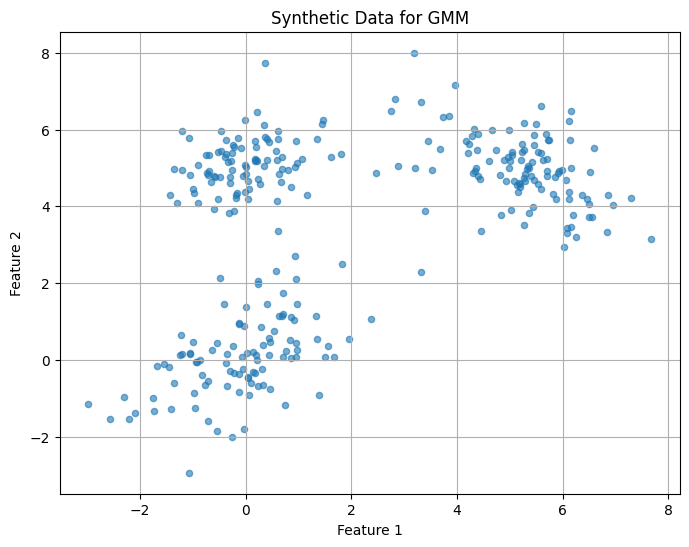

In [ ]:
# Generate synthetic data
np.random.seed(42)
n_samples = 300
k_true = 3 # True number of clusters

# True means and standard deviations for the clusters
means_true = np.array([[0, 0], [5, 5], [0, 5]])
covs_true = [
    np.array([[1, 0.5], [0.5, 1]]),
    np.array([[1, -0.5], [-0.5, 1]]),
    np.array([[0.5, 0], [0, 0.5]])
]
weights_true = np.array([0.3, 0.4, 0.3])

data = np.zeros((n_samples, 2))
for i in range(n_samples):
    cluster = np.random.choice(k_true, p=weights_true)
    data[i] = np.random.multivariate_normal(means_true[cluster], covs_true[cluster])

plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], s=20, alpha=0.6)
plt.title('Synthetic Data for GMM')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

/tmp/ipykernel_3977/4032696077.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  responsibilities[i, j] = weights[j] * multivariate_normal_pdf(data[i], means[j], covariances[j])


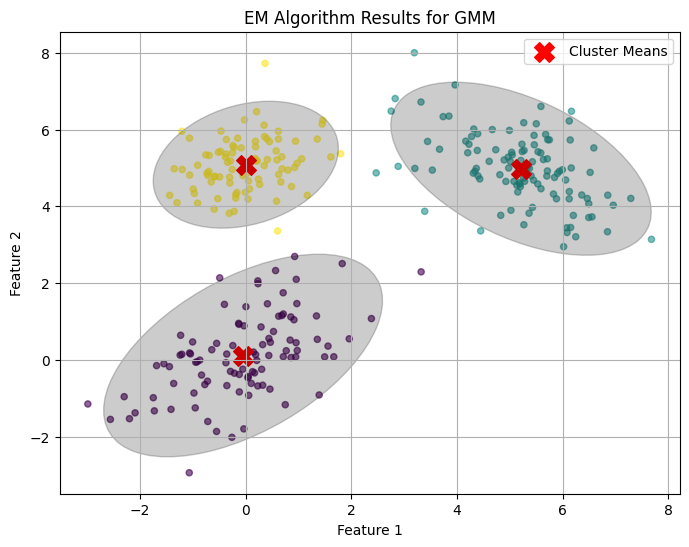

In [ ]:
# Run the EM algorithm
k = 3 # Number of clusters to find
means_em, covariances_em, weights_em, responsibilities_em = em_algorithm(data, k)

# Visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c=np.argmax(responsibilities_em, axis=1), s=20, alpha=0.6, cmap='viridis')
plt.scatter(means_em[:, 0], means_em[:, 1], marker='X', s=200, color='red', label='Cluster Means')

# Plot covariance ellipses
for i in range(k):
    eigenvalues, eigenvectors = np.linalg.eigh(covariances_em[i])
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * np.sqrt(5.991 * eigenvalues) # 95% confidence ellipse
    ellipse = plt.matplotlib.patches.Ellipse(xy=means_em[i], width=width, height=height, angle=angle, color='black', alpha=0.2)
    plt.gca().add_artist(ellipse)

plt.title('EM Algorithm Results for GMM')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()